In [23]:
import json
import itertools
import time
from multiprocessing import Pool as pool
from tqdm import tqdm
from sage.rings.real_arb import RealBall
import numpy as np

In [24]:
load("../code/number_theoretic_dde_solutions.py")

In [25]:
load("IncreasingBooleanFunctions.py")

In [26]:
def proj_Pi(k, F_index, prime=False):
    """
    Computes the projection on the first two coordinates of the polytopes Pi_F
    defined by those (α, β, t) for which t is in Δ_F(α, β) (or Δ_F'(α, β) if prime is set to True)
    """
    ifp = (lambda l: []) if prime else (lambda l: l)

    ieqs = []

    # t_k > b - a
    if k >= 1:
        l=[0, 1, -1] + [0]*(k-1) + [1] + ifp([0])
        ieqs.append(l)
        
    # t_{i+1} < t_i for all 1 <= i <= k-1
    if k >= 2:
        for i in range(1,k):
            l=[0]*(i+2)+[1, -1]+[0]*(k-1-i) + ifp([0])
            ieqs.append(l)

    # b > t_1
    l = [0, 0, 1] + [-1] + [0]*(k-1) + ifp([0])
    ieqs.append(l)

    # s + \sum_j t_j < 1
    # (\sum_j t_j < 1  if prime)
    l = [1, 0, 0] + [-1] * k + ifp([-1])
    ieqs.append(l)

    # if not prime, then s > b
    if not prime:
        l = [0, 0, -1] + [0]*k + [1]
        ieqs.append(l)
    
    Delta_plus = maximal_points[k][F_index]
    for J in Delta_plus:
        l = [-1, 1, 0] + [1-int(i) for i in J] + ifp([1])
        ieqs.append(l)

    Delta_moins = minimal_points[k][F_index]
    for J in Delta_moins:
        l = [0, 0, -1] + [int(i) for i in J] + ifp([0])
        ieqs.append(l)

    # 0 < a
    l = [0, 1, 0] + [0]*k + ifp([0])
    ieqs.append(l)
    # a < b
    l = [0, -1, 1]  + [0]*k + ifp([0])
    ieqs.append(l)
    # b < 1/2
    l = [1, 0, -2] + [0]*k + ifp([0])
    ieqs.append(l)
    
    def prab(x):
        return (x[0], x[1])

    P = Polyhedron(ieqs = ieqs, base_ring = QQ)
    return Polyhedron([prab(v) for v in P.vertices()])


def work_testall(l):
    k, F_index, prime = l
    if proj_Pi(k, F_index, prime=prime).is_full_dimensional():
        return F_index
    return None

def all_Pi(k):
    """ Computes the same projection as above, for all F. """
    cp = []
    c = []
    if k not in increasing_boolean_functions_reduced:
        return [[], []]
    worklist = [(k, F_index, False) for F_index in range(len(increasing_boolean_functions_reduced[k]))]
    print(f" k = {k}, c...")
    with pool(7) as p:
        res = p.map(work, worklist)
    c = [P for P in res if P is not None]
    print("   done")

    worklist = [(k, F_index, True) for F_index in range(len(increasing_boolean_functions_reduced[k]))]
    print(f" k = {k}, c...")
    with pool(7) as p:
        res = p.map(work_testall, worklist)
    cp = [P for P in res if P is not None]
    print("   done")
    return [c, cp]

# This should be run once, it takes about 15 minutes.

#Bk_nontriv = {}
#for j in range(8):
#    Bk_nontriv[j] = testall(j)

def affiche(k):
    """
    Plots all polytopes in the (α, β) plane relative to a given k.
    In particular this gives the set of all (α, β) which involves at least one such F.
    """
    G = []
    for F_index in calcul_fonctions_booleennes.Bk_indices_red[k]:
        for p in [True, False]:
            Q = proj_Pi(k, F_index, prime=p)
            if Q.is_full_dimensional():
                G.append(Q.plot(xmin=0, xmax=1, ymin=0, ymax=1))
    return add(G) + plot(x, (x, 0, 1), color="red") + plot(x+1/k, (x, 0, 1.0000000001-1/k), color="red") + plot(2*x, (x, 0, 0.5), color="red")

What follows will help define a fast function which, given (α, β), returns the list of all F for which Δ_F(α, β) is non-empty.
In practice this set is quite a bit smaller than the full set of F, so this makes the computation quite faster.
It requires a precomputation of about 15 minutes.

In [27]:
def infos_ab(k):
    ab_coeffs = np.empty((0, 3), dtype = np.int64)
    ab_index = np.empty((0, 1), dtype = np.int64)
    ab_prime = np.empty((0, 1), dtype = np.bool)
    for F_index in tqdm(range(len(increasing_boolean_functions_reduced[k]))):
        for prime in [True, False]:
            P = proj_Pi(k, F_index, prime=prime)
            if P.is_full_dimensional():
                ieqs = P.inequalities_list()
                ab_coeffs = np.append(ab_coeffs, np.array(ieqs, dtype = np.int64), axis=0)
                ab_index = np.append(ab_index, np.int64(F_index) * np.ones((len(ieqs), 1), dtype=np.int64))
                ab_prime = np.append(ab_prime,
                                     (np.ones if prime else np.zeros)((len(ieqs), 1), dtype=np.bool))
    return [ab_coeffs, ab_index, ab_prime]

# This should be run once if you haven't done it already. Run the subsequent "ecrit_liste_ab()" to store the result on the disk.
# Takes about 15 minutes

#list_infos_ab = {}
#for k in increasing_boolean_functions_reduced:
#    list_infos_ab[k] = infos_ab(k)

In [28]:
def ecrit_liste_ab():
    """
    Stores list_infos_ab in list_infos_ab.npz: for each k, the arrays
    coeffs_k (int64, shape (n, 3)), index_k (int64, length n) and
    prime_k (bool, length n).
    """
    global list_infos_ab
    if "list_infos_ab" not in globals():
        return
    arrays = {}
    for k, (coeffs, index, prime) in list_infos_ab.items():
        arrays[f"coeffs_{k}"] = np.asarray(coeffs, dtype=np.int64)
        # infos_ab leaves index and prime with shape (0, 1) when they are empty
        arrays[f"index_{k}"] = np.asarray(index, dtype=np.int64).ravel()
        arrays[f"prime_{k}"] = np.asarray(prime, dtype=bool).ravel()
    np.savez_compressed("list_infos_ab.npz", **arrays)

def lit_liste_ab():
    global list_infos_ab
    with np.load("list_infos_ab.npz") as archive:
        ks = sorted({int(name.split("_")[1]) for name in archive.files})
        list_infos_ab = {k: [archive[f"coeffs_{k}"], archive[f"index_{k}"], archive[f"prime_{k}"]]
                         for k in ks}

In [29]:
# ecrit_liste_ab()

In [30]:
# Having done the computation, we get it back from the disk
lit_liste_ab()

In [31]:
def whichF(a, b, k):
    d = ZZ(lcm(a.denominator(), b.denominator()))
    na = ZZ(a * d)
    nb = ZZ(b * d)
    vectest = np.array([d, na, nb], dtype = np.int64).transpose()
    vec_lincomb = np.matmul(list_infos_ab[k][0], vectest)
    vec_indice = np.array(list_infos_ab[k][1], dtype = np.int64)
    vec_prime = np.array(list_infos_ab[k][2], dtype = np.bool)
    vec_excl_indice = vec_indice[vec_lincomb < 0]
    vec_excl_prime = vec_prime[vec_lincomb < 0]
    vec_excl_indice_p0 = np.unique(vec_excl_indice[vec_excl_prime == False])
    vec_excl_indice_p1 = np.unique(vec_excl_indice[vec_excl_prime == True])
    vec_all_p0 = np.unique(vec_indice[vec_prime == False])
    vec_all_p1 = np.unique(vec_indice[vec_prime == True])
    vec_incl_p0 = vec_all_p0[np.logical_not(np.isin(vec_all_p0, vec_excl_indice_p0))]
    vec_incl_p1 = vec_all_p1[np.logical_not(np.isin(vec_all_p1, vec_excl_indice_p1))]
    vec_incl = np.union1d(vec_incl_p0, vec_incl_p1)
    return [vec_incl, np.isin(vec_incl, vec_incl_p0), np.isin(vec_incl, vec_incl_p1)]


In [32]:
def domaine(a, b, w, k, F_index, rh=None, om=None, prime=False):

    ifp = (lambda l: []) if prime else (lambda l: l)

    ieqs = []

    eta = b - a

    # t_k > b - a
    if k >= 1:
        l=[-eta] + [0]*(k-1) + [1] + ifp([0])
        ieqs.append(l)
        
    # t_{i+1} < t_i pour tout 1 <= i <= k-1
    if k >= 2:
        for i in range(1,k):
            l=[0]*i+[1, -1]+[0]*(k-1-i) + ifp([0])
            ieqs.append(l)

    # b > t_1
    # si w < b ceci devient w > t_k (c'est la seule inégalité qui change si w < b)
    l = [min(b, w)] + [-1] + [0]*(k-1) + ifp([0])
    ieqs.append(l)

    # s + \sum_j t_j < 1
    # (\sum_j t_j < 1  is prime)
    l = [1] + [-1] * k + ifp([-1])
    ieqs.append(l)

    # si non prime, alors s > b
    if not prime:
        l = [-b] + [0]*k + [1]
        ieqs.append(l)

    if rh is not None:
        # 1 - (t1 + ... + tk) - s < n_majo eta
        # et 1 - (t1 + ... + tk) < n_majo eta si prime
        l=[-1 + rh[1]*eta]+[1]*k + ifp([1])
        ieqs.append(l)
    
        # 1 - (t1 + ... + tk) - s > n_mino a
        # et 1 - (t1 + ... + tk) > n_mino a si prime
        l=[1 - rh[0]*eta] + [-1]*k + ifp([-1])
        ieqs.append(l)

    if om is not None and not prime:
        # s > m_mino b
        l = [-om[0] * b] + [0]*k + [1]
        ieqs.append(l)
        
        # s < m_majo b
        l = [om[1] * b] + [0]*k + [-1]
        ieqs.append(l)
    
    Delta_plus = maximal_points[k][F_index]
    for J in Delta_plus:
        l = [a-1] + [1-int(i) for i in J] + ifp([1])
        ieqs.append(l)

    Delta_moins = minimal_points[k][F_index]
    for J in Delta_moins:
        l = [-b] + [int(i) for i in J] + ifp([0])
        ieqs.append(l)
    
    return(ieqs)

In [33]:
from sage.numerical.mip import MIPSolverException, MixedIntegerLinearProgram

def are_inequalities_compatible(ieqs, dim):
    p = MixedIntegerLinearProgram()
    x = p.new_variable(real = True)
    for ieq in ieqs:
        p.add_constraint(ieq[0] + sum([x[j] * ieq[j] for j in range(1, dim+1)]) >= 0)
    p.set_objective(None)
    try:
        v = p.solve(objective_only = True)
        return True
    except MIPSolverException:
        return False

In [34]:
def Poly_fulldim(ieqs, dim):
    if are_inequalities_compatible(ieqs, dim):
        P = Polyhedron(ieqs = ieqs)
        if P.dimension() == dim:
            return P
    return None

In [35]:
def erreur_absolue(polynome):
    """ Le polyôme est supposé être univarié et à coefficients dans un RealBallField, et sa variable varie entre -1 et 1.
    Renvoie le polynôme P tel que c_i(P) = c_i(polynome).mid(), et un RealBall Delta tel que polynome(t) = P(t) + Delta.
    Ceci sera utilisé pour ce qui concerne Omega(...).
    """
    KB = polynome.base_ring()
    K.<t> = PolynomialRing(Reals(prec=KB.precision()))
    cf = polynome.monomial_coefficients()
    P = K(add([cf[d].mid() * t^d for d in cf]))
    erreur_abs = add([cf[d].rad() for d in cf])
    return (P, erreur_abs)

In [36]:
def Calcul_integrale(polynomial, polytope):
    """ Calcule l'intégrale du polynôme "polynomial" sur le polytope "polytope"
    """
    poly = polynomial.change_ring(QQ)
    return polytope.integrate(poly, algorithm='cone-decompose')

In [40]:
def calcule_I_polyedre_equilibre(QT, prime=False, verbose=False):
    """ Ici QT est une liste  QT = [a, b, w, P0, rh_el, om_el, T0, T1, precision]
    ou [a, b, w, P0, rh_el, T0, T1, precision] si prime=True,
    Calcule l'intégrale sur le polyèdre P0 de la fonction qu'il faut.
    T0 et T1 sont des listes des minorants (resp. majorants) des coordonnées sur P0.
    rh_el et om_el sont un peu travaillés en amont: ce sont des listes de 4 éléments :
    les deux bornes de l'intervalle, le polynômes à coefficients RR constitué des points médiants,
    et les erreurs absolues.
    Renvoie une liste [b, v], avec b un booléen.
    Si b est True, v est la valeur de l'intégrale.
    Si b est False, v est un majorant trivial de l'intégrale.
    """
    if prime:
        a, b, w, P0, rh_el, T0, T1, vol, N, precision = QT
    else:
        a, b, w, P0, rh_el, om_el, T0, T1, vol, N, precision = QT
    printifdbg = print if verbose else (lambda *x:None)

    # Pour que les calculs soient exacts il faut changer l'anneau de rh et om vers QQ avant la suite

    majorant_rh = rh_el[3]
    majorant_om = 1 if prime else om_el[3]
    majorant_produit = 1/mul(T0)
    majoration_triviale = vol * majorant_rh * majorant_om * majorant_produit
    
    if majoration_triviale < 2**(-precision):
        printifdbg(f"  I ≤ {RR(majoration_triviale)}")
        return [majoration_triviale/2, majoration_triviale/2]
        ## ici rh_el[2](-1) est la valeur de la fonction de Dickman au début de l'intervalle
    
    dim = P0.dimension()
    R = PowerSeriesRing(rh_el[2].base_ring(), "x", num_gens=dim)
    PR = R._poly_ring()
    mt = R.gens()
    if prime:
        t = PR.gens()
    else:
        t = PR.gens()[:-1]
        s = PR.gens()[-1]
    centers = [(T0[j]+T1[j])/2 for j in range(dim)]
    rayons = [(T1[j]-T0[j])/2 for j in range(dim)]
    r = [rayons[j] / centers[j] for j in range(dim)]
    P1 = P0.translation([-c for c in centers]).linear_transformation(diagonal_matrix([1/r for r in rayons]))
    facteur_dilat = mul(rayons)

    fonction = mul([(1 + mt[j] * r[j] + O(mt[j]^N)).inverse() for j in range(dim)]).polynomial()

    if prime:
        fonction *= rh_el[2]((1 - add([t[j]*rayons[j] for j in range(dim)]) - add(centers))/(b-a)*2 - rh_el[0] - rh_el[1])
    else:
        fonction *= rh_el[2]((1 - add([t[j]*rayons[j] for j in range(dim-1)]) - s*rayons[-1] - add(centers))/(b-a)*2 - rh_el[0] - rh_el[1])
        fonction *= om_el[2](((s*rayons[-1]+centers[-1])/b * 2 - om_el[0] - om_el[1])/(om_el[1] - om_el[0]))
    fonction.change_ring(QQ)
    homog = fonction.homogeneous_components()

    dmax = max(homog.keys())
    estimation_queue = 0
    for d in range(dmax, -1, -1):
        if d in homog:
            mc = homog[d].monomial_coefficients()
            h_maxi = add([abs(mc[e]) for e in mc])
            new_majo = vol * h_maxi / mul(centers)
            if estimation_queue + new_majo > 2**(-precision):
                break
            estimation_queue += new_majo
    dmax = d
    
    polynome_latte = add([homog[d] for d in homog if d<= dmax])
    valeur = Calcul_integrale(polynome_latte, P1) * facteur_dilat / mul(centers)
    printifdbg(f"  I ≃ {RR(valeur)}, queue ≤ {RR(estimation_queue)} (degré {dmax})")
    return [valeur, estimation_queue]


In [41]:
def estimate(r, d, K):
    def f(N):
        a = r/(1-r)
        return r^(N-1) * add([a^(d-j) * binomial(N+d-1, j) for j in range(d)])
    N = 0
    while f(N) > 2^(-K.precision()):
        N += 1
    return (N, K(f(N)).upper())

In [42]:
def equilibrage_polyedre(P, K, verbose=False):
    printifdbg = print if verbose else (lambda *x:None)
    k = P.dimension()
    facteur = QQ(1.3)

    N, prod_Delta = estimate((facteur-1)/(facteur+1), k, K)
    
    nombre_decoupes = []
    decoupe_base = []
    mini, maxi = P.bounding_box()
    for j in range(k):
        decoupe_base.append(mini[j])
        nombre_decoupes.append(int(floor(log(maxi[j]/mini[j])/log(facteur))+1))
    
    printifdbg(f"découpes = {nombre_decoupes}")
    
    planches = []
    for j in range(k):
        planches.append([])
        nc = nombre_decoupes[j]
        vecj = [0] * j + [1] + [0]*(k-1-j)
        for r in range(nc):
            planches[j].append([[-(decoupe_base[j]*(facteur**r))] + vecj, 
                                [(decoupe_base[j]*(facteur**(r+1)))] + [-i for i in vecj]])
    
    Qlist = []
    
    ieqsP = P.inequalities_list()

    def salami(ieqs_list, dim_decoupe):
        if dim_decoupe >= k:
            printifdbg(f" salam calcul")
            res = []
            for ieqs in ieqs_list if not verbose else tqdm(ieqs_list):
                R = Poly_fulldim(ieqs, k)
                if R is not None:
                    T0, T1 = R.bounding_box()
                    vol = R.volume(engine='latte', algorithm='cone-decompose')
                    res.append([R, T0, T1, vol])
            return res
        res = []
        printifdbg(f" salam dim {dim_decoupe+1}/{k}")
        for ieqs in ieqs_list if not verbose else tqdm(ieqs_list):
            for j in range(nombre_decoupes[dim_decoupe]):
                ieqsR = ieqs + planches[dim_decoupe][j]
                if are_inequalities_compatible(ieqsR, k):
                    res.append(ieqsR)
        return salami(res, dim_decoupe+1)
    Qlist = salami([ieqsP], 0)

    """
    iterator = itertools.product(*[range(r) for r in nombre_decoupes])
    for u in iterator if not verbose else tqdm(iterator, total=mul(nombre_decoupes), position=0):
        ieqs = []
        for j in range(k):
            pl = planches[j][u[j]]
            ieqs = ieqs + pl
        Q = Poly_fulldim(ieqsP + ieqs, k)
        if Q != None:
            T0, T1 = Q.bounding_box()
            vol = Q.volume(engine='latte', algorithm='cone-decompose')
            Qlist.append([Q, T0, T1, vol])
    """

    if verbose:
        printifdbg(f"fin du découpage, nb total = {len(Qlist)}")
    
    return (Qlist, N, prod_Delta)

In [43]:
def h_bar1(a, b, w, verbose=False, precision=20):
    printifdbg = print if verbose else (lambda *x:None)
    a, b, w = QQ(a), QQ(b), QQ(w)
    if 1-a < b:
        a, b = 1-b, 1-a
    eta = b-a

    K = RealBallField(precision)
    if w <= eta or w < b:
        return K(0)

    # TEST qui ne fonctionne QUE avec w = 1
    Om = BuchstabB(precision = precision)
    Om(max(6, 1/b))

    res = Om(1 + 1/b) - Om(1 + (1 - a)/b)
    printifdbg(f"  première intégrale : {res.endpoints()}")
    return res


In [44]:
def h_bar2(a, b, w, verbose=False, precision=20, kborne=8):
    printifdbg = print if verbose else (lambda *x:None)
    a, b, w = QQ(a), QQ(b), QQ(w)
    if 1-a < b:
        a, b = 1-b, 1-a
    eta = b - a

    K = RealBallField(precision)
    if a == 0:
        return K(0)
    if w <= eta:
        return K(0)

    if w >= b:
        Om = BuchstabB(precision=precision)
        Om(max(6, 1/b))
    Rh = DickmanRho(precision=precision)
    Rh(1/(b-a))

    # troncation maximale pour la fonction rho, puis pour la fonction Omega
    n_max = floor(1/(b-a))
    m_max = 1/b

    Rh_list = [el for el in Rh.approximants_list() if el[0]<=n_max]
    if w >= b:
        Om_list = [el for el in Om.approximants_list() if 1<=el[0]<=m_max]
    else:
        Om_list = []

    res = K(0)
    for k in range(2, kborne):
        printifdbg(f"k = {k}")
        F_index_ab = whichF(a, b, k)
        for F_k in range(len(F_index_ab[0])):
            F_index, F_p0, F_p1 = F_index_ab[0][F_k], F_index_ab[1][F_k], F_index_ab[2][F_k]
            printifdbg(f" F = {''.join([str(i) for i in increasing_boolean_functions_reduced[k][F_index]])}")
            for rh in Rh_list:
                rh_poly, rh_eps = erreur_absolue(rh[2])
                majorant_rh = add([c.abs() for c in rh_poly.coefficients()])
                rh_el = (rh[0], rh[1], rh_poly, majorant_rh)
                if F_p1:
                    # intégrale sur Delta'
                    P1 = Poly_fulldim(domaine(a, b, w, k, F_index, rh=rh, prime=True), k)
                    if P1 is not None:
                        mini, maxi = P1.bounding_box()
                        majorant_produit_P1 = 1/mul(mini)
                        majoration_triviale = P1.volume() * majorant_produit_P1 * majorant_rh
                        if majoration_triviale < 2^(-precision):
                            printifdbg(f"  volume nul ({majoration_triviale})")
                            res += K(majoration_triviale/2, rad=majoration_triviale/2)
                            continue
                        Qlist, N, prod_Delta = equilibrage_polyedre(P1, K, verbose=verbose)
                        nb_decoupe_total = len(Qlist)
                        res_new = K(0)
                        for P, T0, T1, vol in Qlist:
                            integrale = calcule_I_polyedre_equilibre([a, b, w, P, rh_el, T0, T1, vol, N, precision], prime=True, verbose=False)
                            val = K(integrale[0], rad=integrale[1])
                            majorant_produit = 1/mul(T0)
                            prod_eps = majorant_produit * prod_Delta
                            res_new += K(val).add_error(vol*((majorant_produit+prod_eps)*rh_eps + prod_eps*majorant_rh))
                        if integrale[0] and verbose:
                            printifdbg(f"  rho sur ({rh[0]}, {rh[1]})")
                            printifdbg(f"   termes = {res_new.endpoints()}")
                        res += res_new
                if F_p0:
                    for om in Om_list:
                        P1 = Poly_fulldim(domaine(a, b, w, k, F_index, rh=rh, om=om), k+1)
                        if P1 == None:
                            continue
                        mini, maxi = P1.bounding_box()
                        majorant_produit_P1 = 1/mul(mini)
                        majoration_triviale = P1.volume() * majorant_produit_P1 * majorant_rh
                        if majoration_triviale < 2^(-precision):
                            printifdbg(f"  volume nul ({majoration_triviale})")
                            res += K(majoration_triviale/2, rad=majoration_triviale/2)
                            continue
                        Qlist, N, prod_Delta = equilibrage_polyedre(P1, K, verbose=verbose)
                        nb_decoupe_total = len(Qlist)
                        res_new = K(0)
                        om_poly, om_eps = erreur_absolue(om[2])
                        majorant_om = add([c.abs() for c in om_poly.coefficients()])
                        om_el = (om[0], om[1], om_poly, majorant_om)
                        # Il faudrait précalculer tous ces polynômes lors de la construction de rh et om
                        # car là on les recalcule plein de fois
                        for P, T0, T1, vol in Qlist:
                            integrale = calcule_I_polyedre_equilibre([a, b, w, P, rh_el, om_el, T0, T1, vol, N, precision], verbose=False)
                            val = K(integrale[0], rad=integrale[1])
                            majorant_produit = 1/mul(T0)
                            prod_eps = majorant_produit * prod_Delta
                            res_new += K(val).add_error(vol*((majorant_produit+prod_eps)*(majorant_rh+rh_eps)*om_eps
                                                             + (majorant_produit+prod_eps)*rh_eps*majorant_om
                                                             + prod_eps*majorant_rh*majorant_om))
    
                        if res_new != 0 and verbose:
                            printifdbg(f"  rho sur ({rh[0]}, {rh[1]}) / om sur ({om[0]}, {om[1]})")
                            printifdbg(f"   termes = {RR(res_new)}")
                        res += res_new
    return res
    

In [45]:
def tronque_k(a, b, w, kborne=8, precision=20, verbose=False):
    printifdbg = print if verbose else (lambda *x:None)
    k_max = 1
    eta = b - a
    K = RealBallField(precision)
    def jauge_k(k0):
        if eta > 1/k0:
            return 0
        if b > 2*a:
            return 0
        E1 = max(0, 1/eta-k0)^k0/factorial(k0)^2
        u = (1-a)*(b-a)/a
        E2 = RR(exp(euler_gamma)) * (1 - u * sum([log(1/u)^m / factorial(m) for m in range(k0)]))
        E3 = 1
        return RR(min(E1, E2, E3))
    while k_max<kborne and jauge_k(k_max) > 2**(-precision):
        k_max += 1
    erreur_k = RR(jauge_k(k_max))
    printifdbg(f"k<{k_max}")
    printifdbg(f" [la troncation de k induit une erreur {erreur_k}]")
    return [k_max, K(erreur_k/2, rad=erreur_k/2)]


In [46]:
def h_bar(a, b, w, verbose=False, precision=(20, 20), kborne=8):
    t1 = time.time()
    k_max, erreur_k = tronque_k(a, b, w, kborne, precision[1], verbose)
    hv1 = h_bar1(a, b, w, verbose, precision[0])
    hv2 = h_bar2(a, b, w, verbose, precision[1], k_max)
    val = hv1 + hv2 + erreur_k
    t2 = time.time()
    # (val 1ère intégrale, val 2ème intégrale, erreur de troncation sur k, valeur totale, temps mis)
    return (hv1, hv2, erreur_k, val, round(t2-t1, 3))

In [47]:
h_bar(0.4, 0.6, 1, precision=(50, 14), verbose=True)

k<5
 [la troncation de k induit une erreur 3.83829713559753e-80]
  première intégrale : (0.51082562376596, 0.51082562376601)
k = 2
k = 3
k = 4


([0.5108256237660 +/- 3.08e-14], 0, [+/- 3.84e-80], [0.511 +/- 3.19e-4], 0.013)

In [48]:
%%time
val = h_bar(1/6, 1/2, 1, precision=(50, 20), verbose=True)
val

k<1
 [la troncation de k induit une erreur 0.000000000000000]
  première intégrale : (0.18232155679393, 0.18232155679399)
CPU times: user 12.2 ms, sys: 15 µs, total: 12.2 ms
Wall time: 11.9 ms


([0.1823215567940 +/- 6.80e-14], 0, 0, [0.182322 +/- 6.90e-7], 0.012)

In [49]:
%%time
val = h_bar(0.45, 0.5, 1, precision=(50, 14), verbose=False, kborne=8)
val

CPU times: user 5.09 s, sys: 27.8 ms, total: 5.11 s
Wall time: 5.79 s


([0.5978370007556 +/- 4.84e-14],
 [0.02 +/- 3.26e-3],
 [+/- 0.0144],
 [0.6 +/- 0.0355],
 5.794)

In [50]:
def abliste(k, num_points=100):
    ablist = []
    while len(ablist) < num_points:
        b = 0.5*sqrt(random())
        a = b*random()
        if b>a and k-1 <= 1/(b-a) < k:
            a = QQ(round(a, 3))
            b = QQ(round(b, 3))
            ablist.append([a, b])
    return ablist

In [51]:
def work(p):
    #print(f"calcul de h_bar({p[0]}, {p[1]})")
    r = (p[0], p[1], h_bar(p[0], p[1], 1, precision=(50, 14)))
    #print(f"  valeur {r[2]}")
    return r

In [52]:
def init_liste():
    global M
    M = []
    return
    """
    M = [(0., 0.0001, (RBF(0.), RBF(0.), RBF(0.), RBF(0.), 0)),
         (0., 0.5, (RBF(0.), RBF(0.), RBF(0.), RBF(0.), 0)),
         (0.0001, 0.0001, (RBF(1.), RBF(0.), RBF(0.), RBF(1.), 0)),
         (0.5, 0.5, (RBF(1.), RBF(0.), RBF(0.), RBF(1.), 0))]
    """

In [53]:
def ajoute_liste_ab(ablist):
    global M
    if "M" not in globals():
        init_liste()
    npp = 4
    for k in range(ceil(len(ablist)/npp)):
        worklist = ablist[(npp*k):(npp*k+npp)]
        with pool(npp) as pp:
            res = pp.map(work, worklist)
        M = M + res

In [54]:
def ajoute_liste(k, num_points = 100):
    global M
    if k <= 2:
        return
    if "M" not in globals():
        init_liste()
    ablist = abliste(k, num_points)
    print(ablist)
    ajoute_liste_ab(ablist)

In [55]:
def ball_to_json(x):
    """
    The real ball x as a dict, with its midpoint and radius as exact rationals.
    """
    return {"mid": str(x.mid().exact_rational()),
            "rad": str(x.rad().exact_rational()),
            "prec": int(x.parent().precision())}

def ball_from_json(entry):
    """
    Inverse of ball_to_json. add_error rounds the radius outward, so the ball
    returned contains the one that was stored, but may be slightly wider.
    """
    return RealBallField(entry["prec"])(QQ(entry["mid"])).add_error(QQ(entry["rad"]))

def ecrit_liste():
    """
    Stores the sample M in hbar-echantillon.json, one entry per line.
    """
    global M
    if "M" not in globals():
        return
    description = ("Sample of h_bar(a, b, 1). Each entry is [a, b, [hv1, hv2, erreur_k, val, seconds]], "
                   "as returned by h_bar: a and b are exact rationals, seconds is the computation time, "
                   "and the four other values are real balls {mid, rad, prec}, where mid and rad are "
                   "exact rationals and prec is the precision in bits. "
                   "RealBallField(prec)(QQ(mid)).add_error(QQ(rad)) contains the ball that was stored.")
    entries = [json.dumps([str(a), str(b), [ball_to_json(hv1), ball_to_json(hv2), ball_to_json(erreur_k),
                                            ball_to_json(val), float(seconds)]])
               for a, b, (hv1, hv2, erreur_k, val, seconds) in M]
    with open("hbar-echantillon.json", "w") as f:
        f.write('{"description": ' + json.dumps(description) + ',\n "entries": [\n')
        f.write(",\n".join(entries))
        f.write("\n]}\n")

In [56]:
def lit_liste():
    global M
    with open("hbar-echantillon.json") as f:
        entries = json.load(f)["entries"]
    M = [(QQ(a), QQ(b), (ball_from_json(hv1), ball_from_json(hv2), ball_from_json(erreur_k),
                         ball_from_json(val), RDF(seconds)))
         for a, b, (hv1, hv2, erreur_k, val, seconds) in entries]

In [57]:
def affiche_M():
    global M
    if "M" not in globals():
        raise ValueError("La liste est vide.")
    M_inf = [(u[0], u[1], u[2][3].lower()) for u in M]
    M_sup = [(u[0], u[1], min(1, u[2][3].upper())) for u in M]
    return list_plot3d(M_inf, point_list = True, interpolation_type='linear', color="blue") \
    + list_plot3d(M_sup, point_list = True, interpolation_type='linear', color="red")

In [58]:
def abliste_globale(n_grid = 100):
    points = {}
    for i in range(n_grid):
        for j in range(i+1, n_grid+1):
            a, b = QQ(i/n_grid), QQ(j/n_grid)
            if b <= 1/2:
                k = ceil(1/(b-a))
                if k not in points:
                    points[k] = []
                points[k].append((a, b))
    return points

In [59]:
pts_glob = abliste_globale()

In [60]:
init_liste()

In [64]:
lit_liste()

In [ ]:
liste_ab_existants = [(u[0], u[1]) for u in M]
for k in sorted(pts_glob.keys()):
    if k>100:
        break
    print(k)
    pts_new = [ab for ab in pts_glob[k] if ab not in liste_ab_existants]
    ajoute_liste_ab(pts_new)

In [58]:
ecrit_liste()

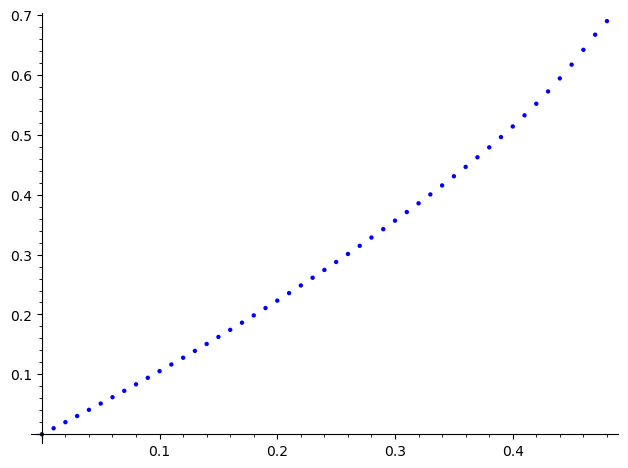

In [66]:
list_plot([(u[0], u[2][3].lower()) for u in M if u[1] == 1/2])

In [99]:
affiche_M()

/home/sary/sage/sage/src/sage/repl/rich_output/display_manager.py:584: UserWarning: Warning: converting a masked element to nan.
  return obj._rich_repr_(self)


Graphics3d Object

In [60]:
from sage.plot.plot3d.shapes2 import Point as Point3d

In [251]:
add([Point3d((u[0], u[1], min(1, u[2][3].upper())), color="red") for u in M])

Graphics3d Object

In [253]:
add([Point3d((u[0], u[1], u[2][3].lower()), color="blue") for u in M])

Graphics3d Object

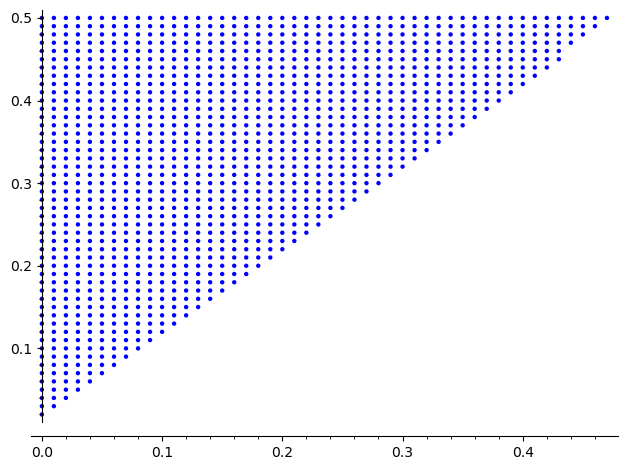

In [54]:
list_plot([(u[0], u[1]) for u in M])

In [14]:
K = RealBallField(14)

In [22]:
for _ in range(4):
    del M[0]

In [130]:
Mdic = {(u[0], u[1]): u[2] for u in M}

In [13]:
[(k, len(increasing_boolean_functions_reduced[k])) for k in increasing_boolean_functions_reduced]

[(1, 0), (2, 1), (3, 4), (4, 16), (5, 91), (6, 1053), (7, 43141)]

In [25]:
def surface_M(e, c):
    G = []
    for v in Mdic:
        v1 = (v[0], v[1]-1/100) 
        v2 = (v[0]+1/100, v[1])
        if v1 in Mdic and v2 in Mdic:
            ev, ev1, ev2 = [e(Mdic[u]) for u in [v, v1, v2]]
            p1 = (v[0], v[1], ev)
            p2 = (v1[0], v1[1], ev1)
            p3 = (v2[0], v2[1], ev2)
            val = (ev+ev1+ev2)/3
            G.append(polygon3d([p1, p2, p3], color=c(val)))

            v3 = (v[0]+1/100, v[1]-1/100)
            if v3 in Mdic:
                ev3 = e(Mdic[v3])
                p4 = (v3[0], v3[1], ev3)
                val = (ev1+ev2+ev3)/3
                G.append(polygon3d([p2, p3, p4], color=c(val)))
                for l in [[p1, p2], [p2, p4], [p4, p3], [p3, p1]]:
                    G.append(line3d(l, color="black"))
            else:
                for l in [[p1, p2], [p2, p3], [p3, p1]]:
                    G.append(line3d(l, color="black"))
    return add(G)

In [34]:
AG = surface_M(lambda v: max(0, 1-v[3].mid()),
               lambda val: (lambda x: Color(0.5,0.5,x))(val))

In [35]:
AG.show(figsize=12, aspect_ratio = [1, 1, 1], viewer="threejs")

Graphics3d Object

In [65]:
add([Point3d((u[0], u[1], (u[2][4]).log()), size=3, marker=",", color=(lambda x: Color(x,x,x))(1-((u[2][4]).log()+5.9)/14.5)) for u in M if u[2][4]>0.00001]).show(axes_labels = ["α", "β", "log(t)"], aspect_ratio = [1, 1, 1/25])

Graphics3d Object

In [ ]:
add([Point3d((u[0], u[1], u[2][3].rad())) for u in M])

In [222]:
add([Point3d((u[0], u[1], u[2][2])) for u in M])

Graphics3d Object

In [ ]:
c = 0
for k in increasing_boolean_functions_reduced:
    for F_index in tqdm(range(len(increasing_boolean_functions_reduced[k]))):
        for p in [True, False]:
            Q = proj_Pi(k, F_index, prime=p)
            if Q.is_full_dimensional() and (4/10, 46/100) in Q:
                c += 1

In [387]:
nb_int = {}
for k in increasing_boolean_functions_reduced:
    for F_index in tqdm(increasing_boolean_functions_reduced[k]):
        for p in [True, False]:
            L = proj_Pi(k, F_index, prime=p).render_points_2d()
            if len(L)>0:
                P = Polyhedron(list(L)[0])
                for v in Mdic:
                    if v not in P:
                        continue
                    if v not in nb_int:
                        nb_int[v] = 1
                    else:
                        nb_int[v] = nb_int[v] + 1

0it [00:00, ?it/s]
100%|██████████| 240/240 [00:36<00:00,  6.63it/s]
